### 1. Import Libraries

First, we'll import the necessary libraries: `tensorflow` for building and training the neural network, `numpy` for numerical operations, and `matplotlib` for plotting (though we won't be plotting in this specific solution, it's good practice to include it for visual exploration if needed).

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

### 2. Load and Preprocess the MNIST Dataset

We'll load the MNIST dataset, which consists of grayscale images of handwritten digits (0-9). Then, we'll perform basic preprocessing:

*   **Reshape:** Images need to be reshaped to include a channel dimension (e.g., `(28, 28, 1)` for grayscale images).
*   **Normalize:** Pixel values are scaled from `[0, 255]` to `[0, 1]` for better training performance.
*   **One-hot Encode Labels:** Convert integer labels into a one-hot encoded format (e.g., `3` becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`).

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocessing
# Reshape data to add a channel dimension (for grayscale, it's 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values to be between 0 and 1
x_train /= 255
x_test /= 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


### 3. Define the Convolutional Neural Network (CNN) Model

We'll create a `Sequential` model with the specified architecture:

*   **Conv2D (1st layer):** 32 filters, `3x3` kernel, ReLU activation, input shape `(28, 28, 1)`.
*   **MaxPooling2D (1st pooling):** `2x2` pool size.
*   **Conv2D (2nd layer):** 64 filters, `3x3` kernel, ReLU activation.
*   **MaxPooling2D (2nd pooling):** `2x2` pool size.
*   **Flatten:** Converts the 2D feature maps into a 1D vector.
*   **Dense (1st fully connected):** 128 units, ReLU activation.
*   **Dropout:** 0.5 rate for regularization to prevent overfitting.
*   **Dense (Output layer):** 10 units (for 10 classes), Softmax activation for probability distribution.

In [3]:
# Define the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

Now, we'll train the model using the `x_train` and `y_train` data. We'll train for 10 epochs with a batch size of 128. A `validation_split` is used to monitor performance on unseen data during training.

In [4]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accuracy: 0.9010 - loss: 0.3236 - val_accuracy: 0.9818 - val_loss: 0.0612
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 100ms/step - accuracy: 0.9680 - loss: 0.1056 - val_accuracy: 0.9873 - val_loss: 0.0440
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9768 - loss: 0.0782 - val_accuracy: 0.9872 - val_loss: 0.0437
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9811 - loss: 0.0624 - val_accuracy: 0.9898 - val_loss: 0.0346
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9838 - loss: 0.0536 - val_accuracy: 0.9912 - val_loss: 0.0332
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9855 - loss: 0.0468 - val_accuracy: 0.9912 - val_loss: 0.0310
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9870 - loss: 0.0408 - val_accuracy: 0.9907 - val_loss: 0.0322
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9887 - loss: 0.0365

### 5. Evaluate the Model

Finally, we'll evaluate the trained model on the test dataset (`x_test`, `y_test`) to determine its performance (loss and accuracy) on completely new, unseen images.

In [5]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0235
Test Accuracy: 0.9925


### Optional: Visualize Training History

You can optionally plot the training and validation accuracy and loss over epochs to see how the model learned.

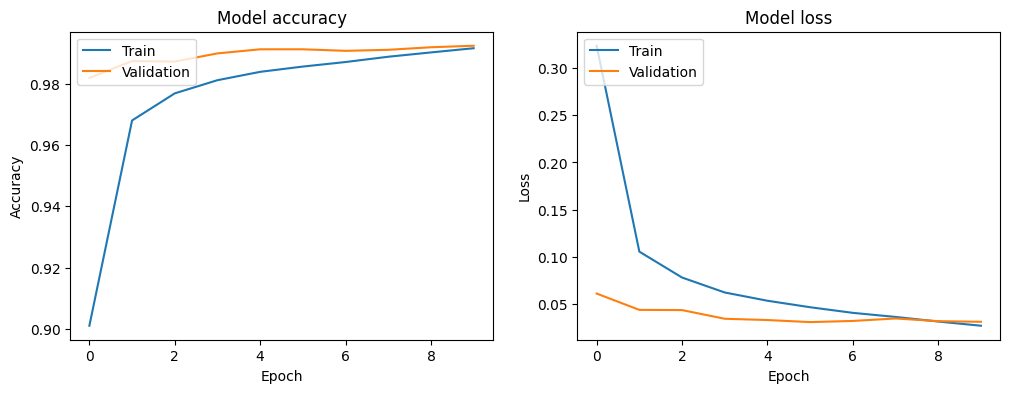

In [6]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()